In [ ]:
import blue_sampler as blue
def show_result(x):
    """
    plot the points x (N, D)
    and estimated structure factor (using scattering intensity)

    in 3D or more, points are projected on the 3 first axes before ploting
    """
    blue.plot(x, auto_zoom = True)
    blue.plot_structure_factor(x)

def centroids(x):
    """ 
    Comput barycenter of each batch.
    input configuration: x (B, K, D) -> output points (B, D)
    """
    return x.mean(axis = 1)

## Sample methods

blue_sampler can generate well-distributed configurations on the unit torus [0,1)**D, either as points, clusters, or tessellations. 

A repulsive interaction energy (for sample_points) or a fair partition criterion \
of space (e.g. the same number of atoms per cluster or equal area per tessellation) \
leads to the disappearance of density fluctuations at low ("blue") frequencies.

In [7]:
N = 2**15
D = 2

✦ 2D blue-noise pipeline — sampling 32,768 points
[Level 3 : N =  1214] done 27s             
[Level 2 : N =  3642] done 3s                                   
[Level 1 : N = 10924] done 7s                                   
[Level 0 : N = 32768] done 15s                                   
Done — visualise with blue.plot(x)


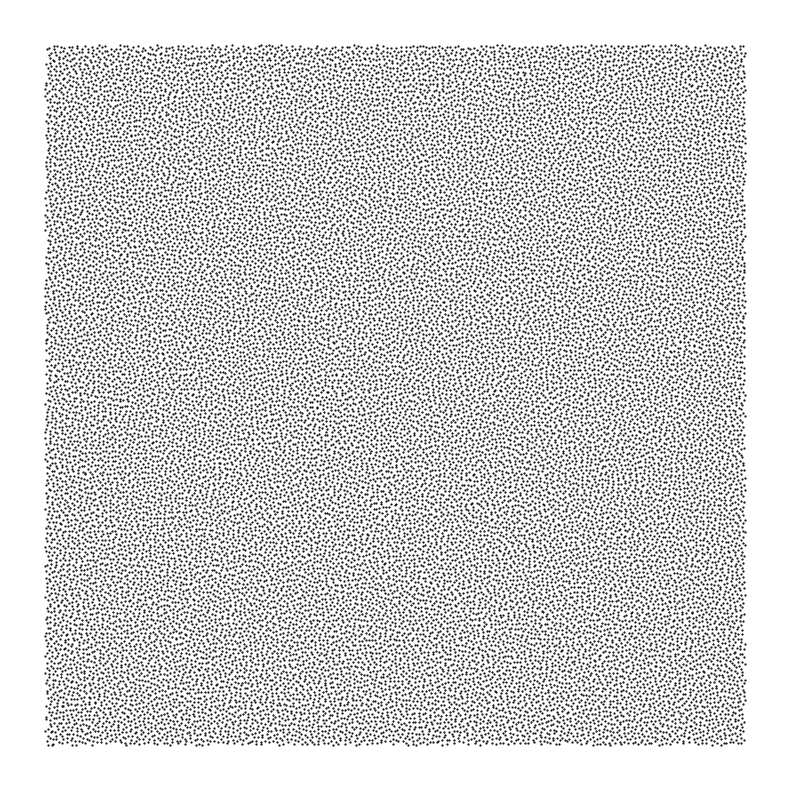

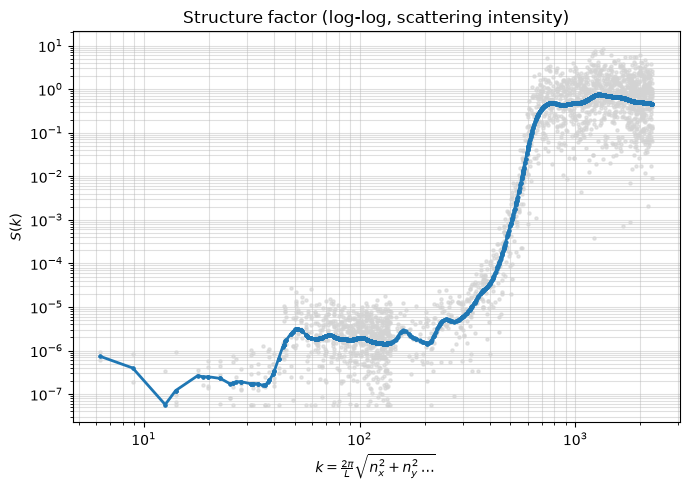

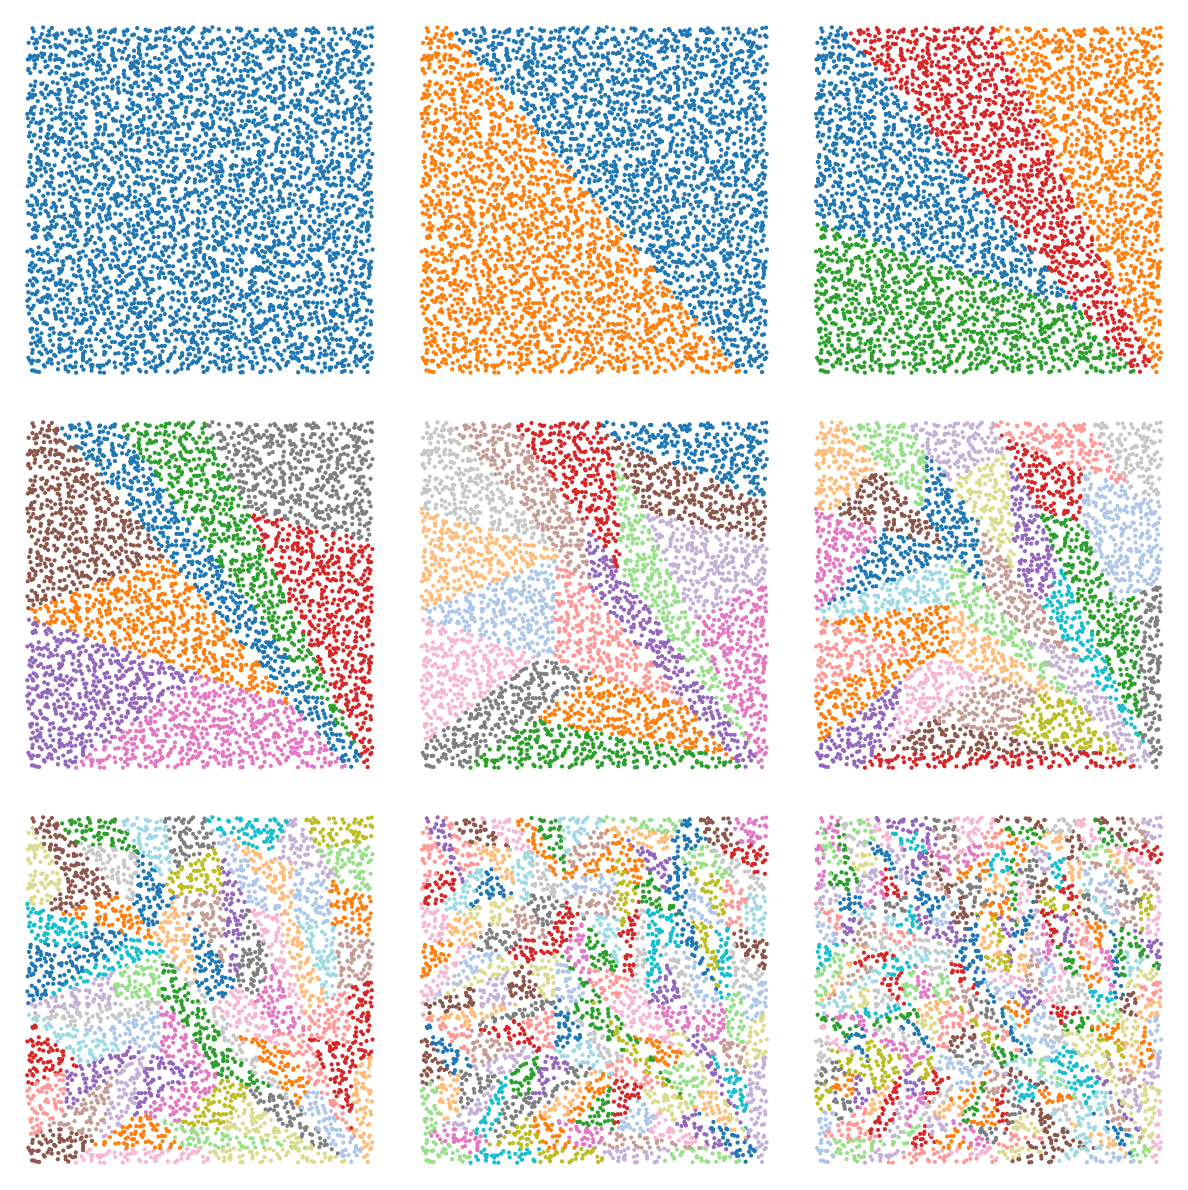

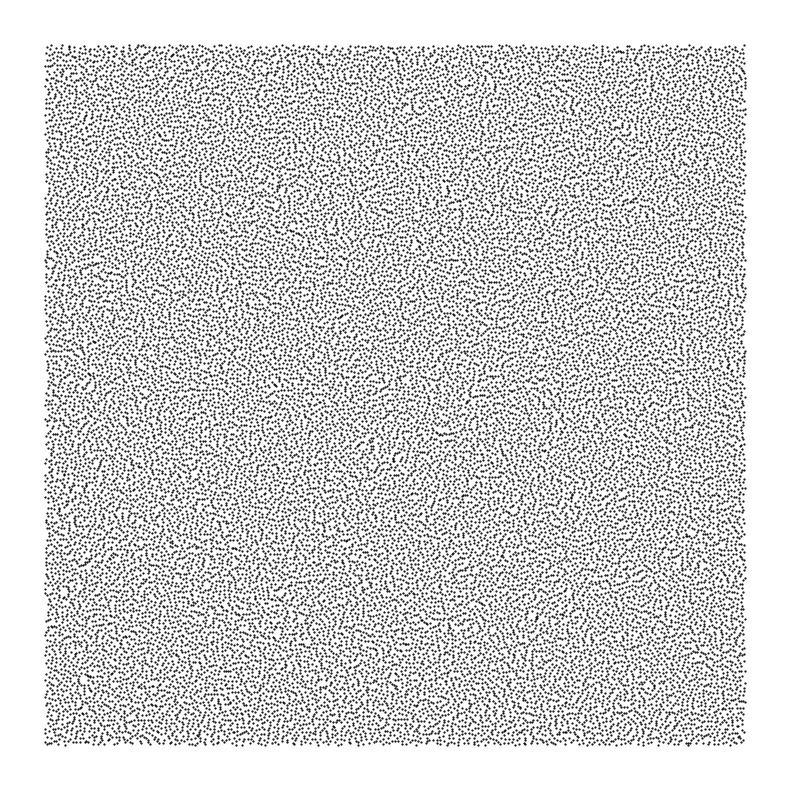

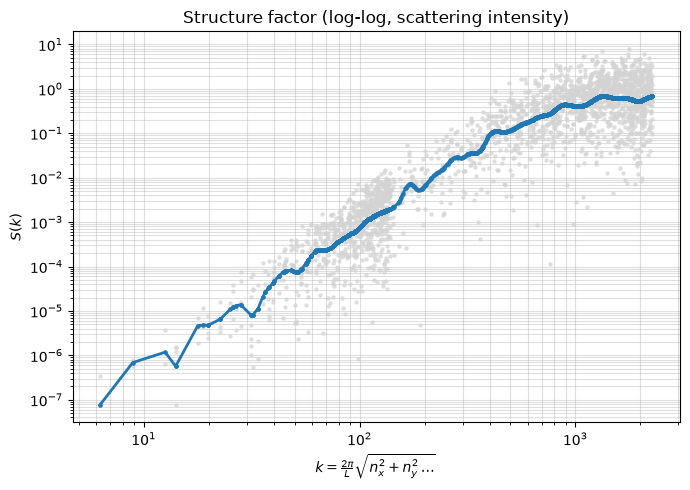

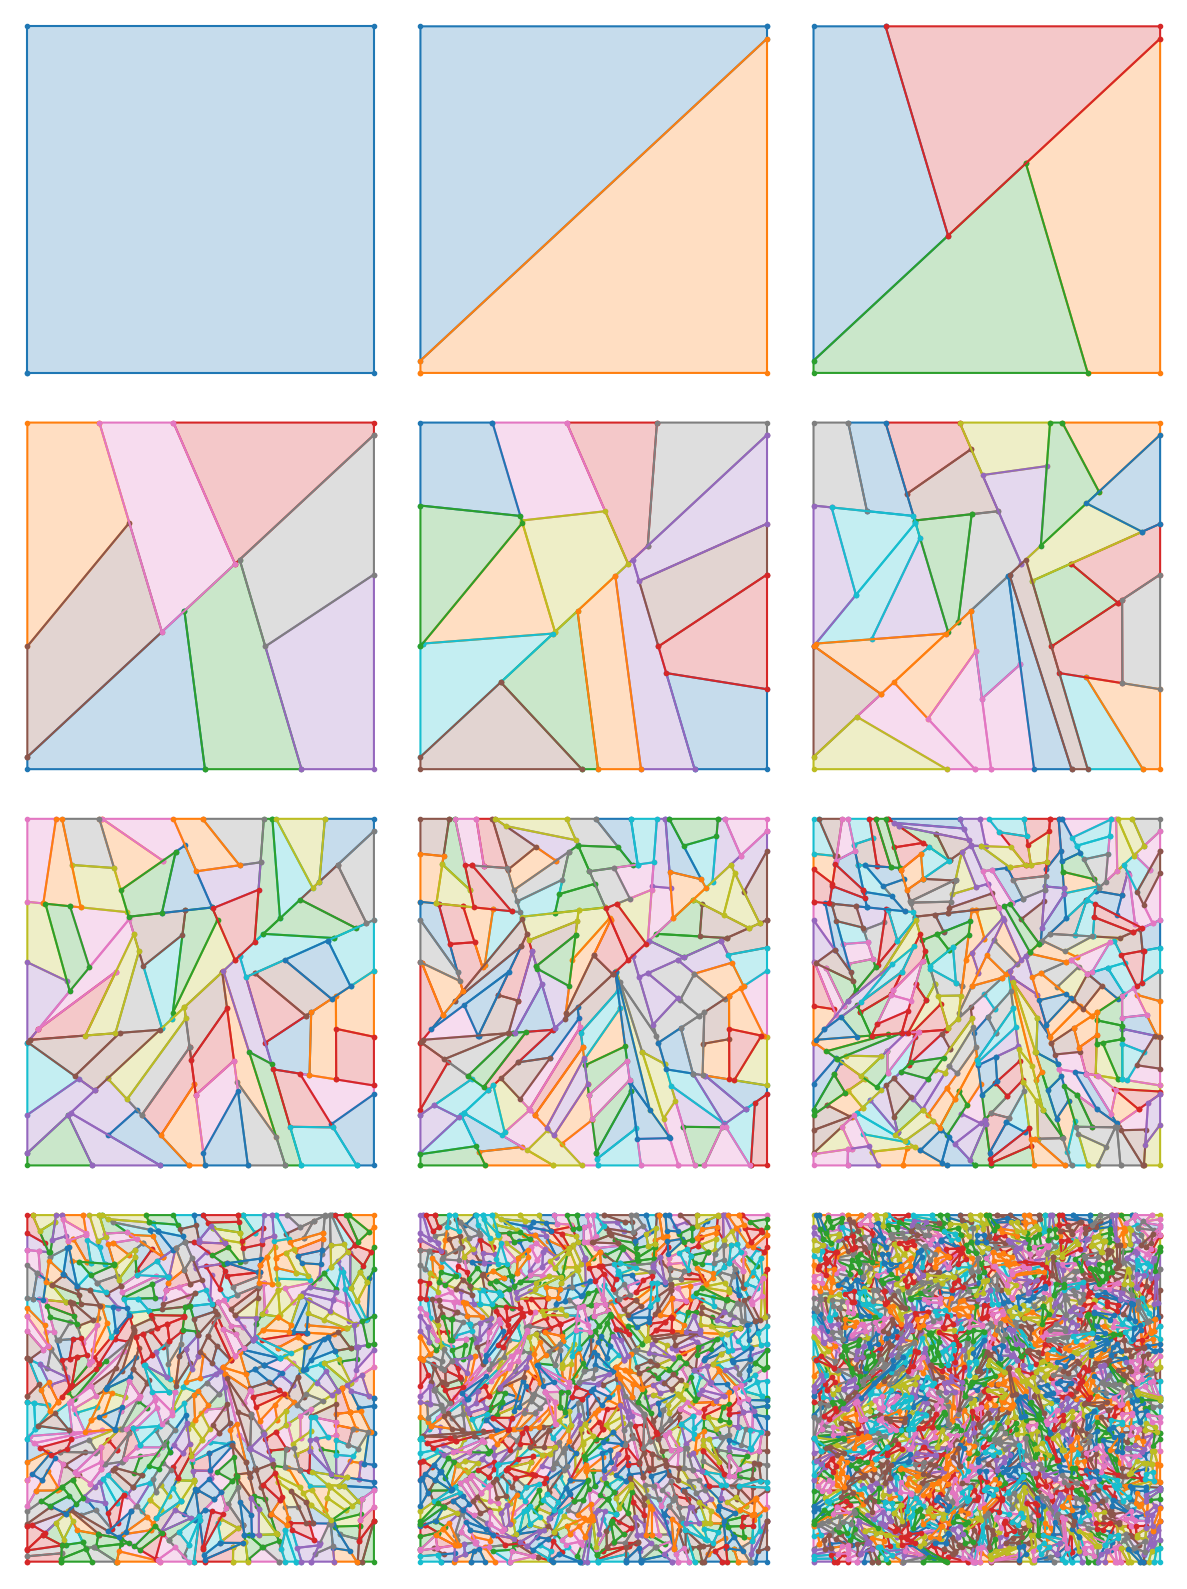

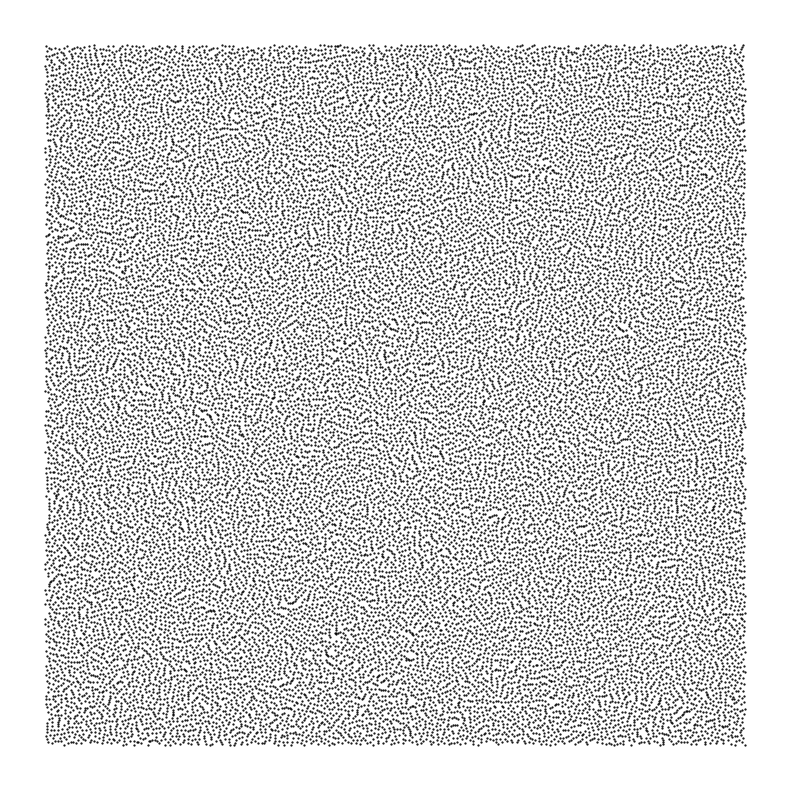

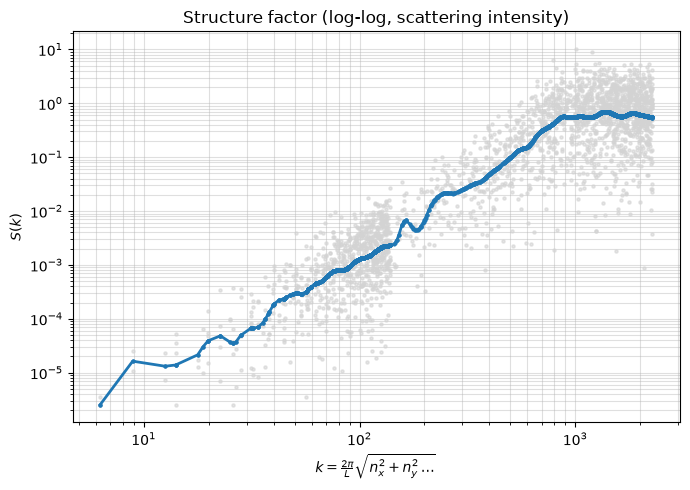

In [3]:
x = blue.sample_points(N = N, D = D) #set of particles with minimal gaussian interaction
show_result(x) 

y = blue.sample_clusters(N = N, D = D) #clusters of a random point set (default Sobol)
blue.plot_clusters(y)
show_result(centroids(y)) 

z = blue.sample_tessels(N = N, D = D) #random quadrilaterals with same area
blue.plot_tessels(z)
show_result(centroids(z))

## Moment matching

To convert a geometric configuration (either a batch of clusters or a batch of polygons)
into a point set, we can replace the centroid method that we used in previous cell by a more
power full moment-matching method. 

The idea of moment matching is to replace the geometric configuration by n points per batch
(instead of just a single point placed at the batch barycentre) by enforcing consistency between 
the empirical moments of the points and the prescribed geometry.

blue.tessel2points and blue.cluster2points will perform moment matching, i.e place **n points per batch** (default 6) \
to fit moments **up to order p** (default 3) of the given geometry (tessels or clusters)


✦ 2D Moment matching pipeline — sampling 32,768 x 3 points

Matching target… [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓] 20/20  ETA  2s          
Done


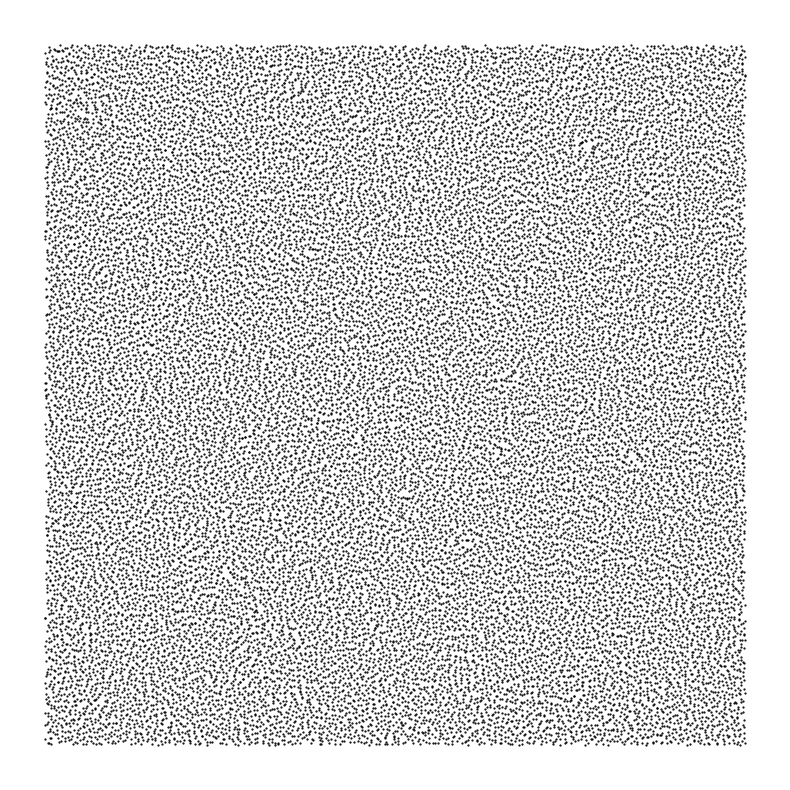

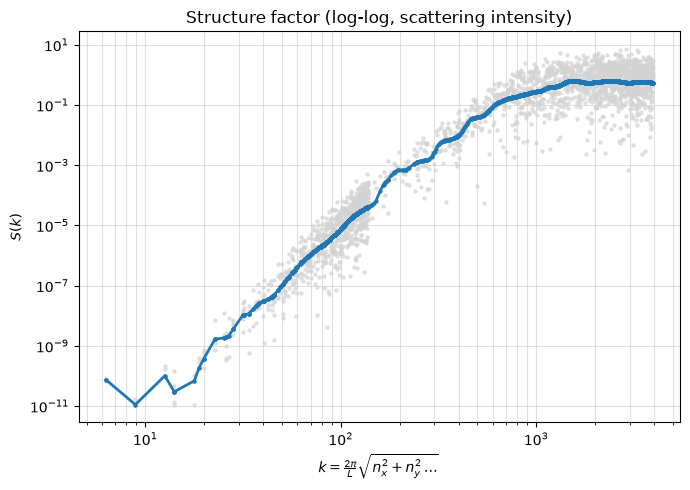

In [9]:
u = blue.cluster2points(y) #moment matching between clusters y and points u
show_result(u)

✦ 2D Moment matching pipeline — sampling 32,768 x 3 points

Matching target… [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓] 20/20  ETA  2s          
Done


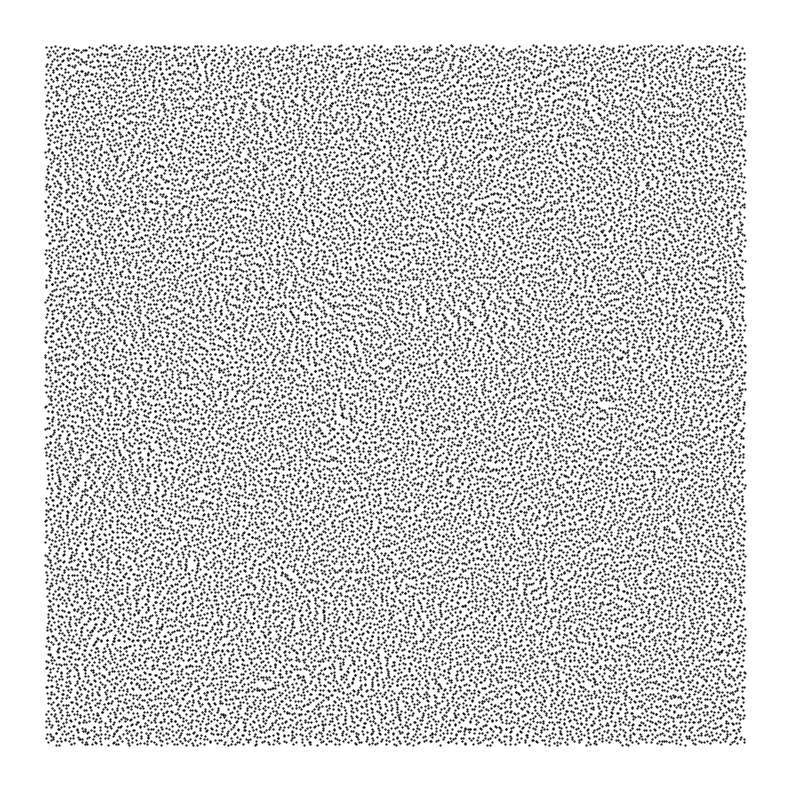

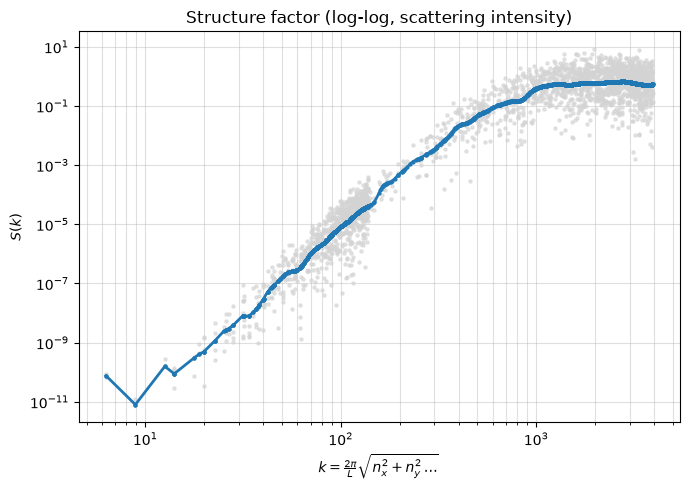

In [10]:
v = blue.tessel2points(z) #moment matching between tessels z and points v
show_result(v)

## Adaptative sampling

In [5]:
N = 2**16
D = 2

In [6]:
oversampling = 50 
Ntgt = N * oversampling #we oversample the target to avoid overfitting noise
targets = blue.generate_dataset(dataset = "barbara", size = (Ntgt, D), plot_data = False) ## iid target

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


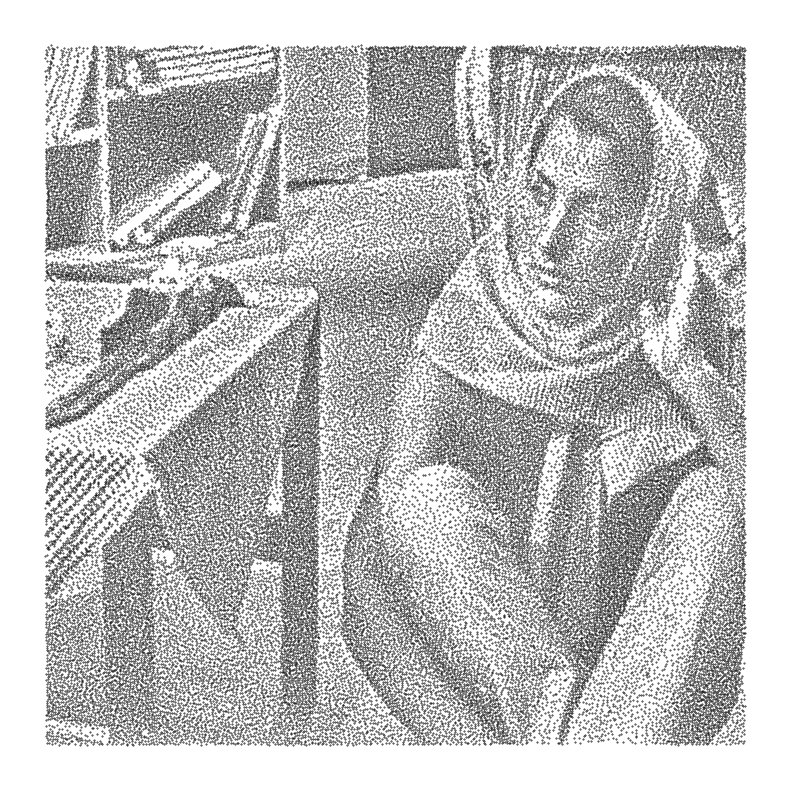

In [7]:
x = centroids(blue.sample_clusters(N = N, D = D, targets = targets)) 
blue.plot(x)

✦ 2D blue-noise pipeline — sampling 65,536 points
[Level 3 : N =  2428] done 5s                                     
[Level 2 : N =  7282] done 5s                                     
[Level 1 : N = 21846] done 13s                                    
[Level 0 : N = 65536] done 28s                                    
Done — visualise with blue.plot(x)


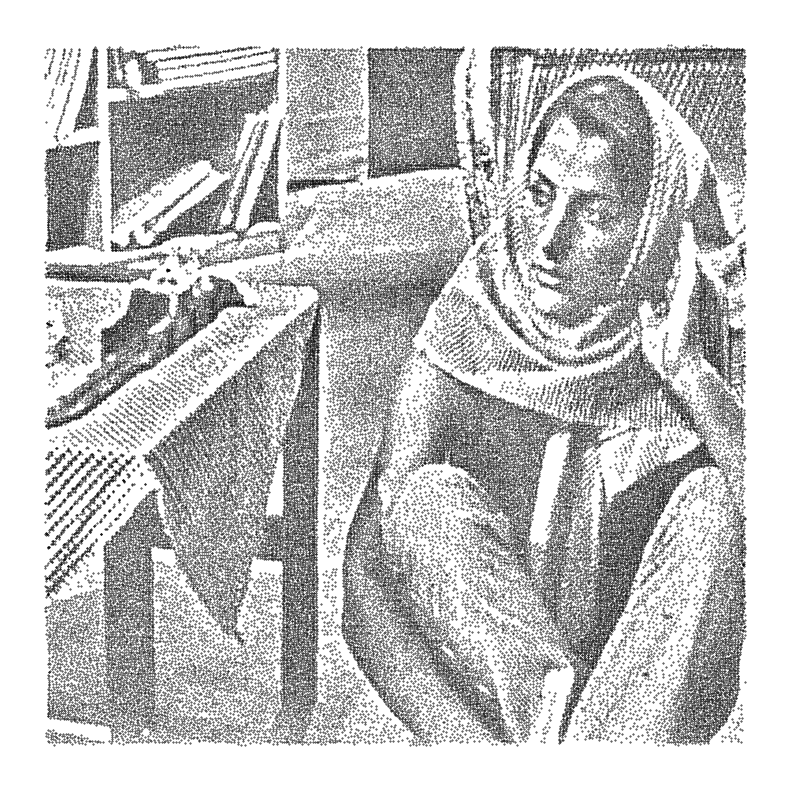

In [8]:
x = blue.sample_points(N = N, D = D, targets = targets)  #slower but much better result
blue.plot(x)